In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
from matplotlib.patches import Patch
import seaborn as sns
from pathlib import Path
import glob
import os
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

## Data preparation

In [2]:
shp_path = 'GUB_Global_2018/GUB_Global_2018.shp'
gdf = gpd.read_file(shp_path)

gdf['centroid'] = gdf.geometry.centroid
gdf['centroid_y'] = gdf['centroid'].y
gdf['hemisphere'] = gdf['centroid_y'].apply(lambda y: 'N' if y >= 0 else 'S')

hemisphere_map = gdf.set_index('ORIG_FID')['hemisphere'].to_dict()

csv_files = sorted(glob.glob('GreenArea_Global/greenspace_*.csv'))
season_map = {'spring': 'fall', 'summer': 'winter', 'fall': 'spring', 'winter': 'summer'}

all_data = []

for csv_file in csv_files:
    basename = os.path.basename(csv_file)
    parts = basename.replace('.csv', '').split('_')
    season = parts[1].lower()
    year = int(parts[2])

    df = pd.read_csv(csv_file)
    df['year'] = year
    df['season_NH'] = season
    df['hemisphere'] = df['ORIG_FID'].map(hemisphere_map)
    
    df['season'] = df.apply(lambda row: season if row['hemisphere']=='N' else season_map[season], axis=1)

    season_order_map = {'spring': 1, 'summer': 2, 'fall': 3, 'winter': 4}
    df['season_order'] = df['season'].map(season_order_map)

    df['time_id'] = df.apply(lambda row: f"{row['year']}-{row['season_order']}", axis=1)
    df['time_label'] = df.apply(lambda row: f"{row['season'][:3].capitalize()} {row['year']}", axis=1)
    
    all_data.append(df)

merged_df = pd.concat(all_data, ignore_index=True)

In [5]:
merged_df.to_csv('greenspace_all.csv', index=False)

## Data analysis

In [2]:
merged_df = pd.read_csv('greenspace_exposure_all.csv')

In [3]:
cities_gdf = gpd.read_file('GUB_Global_2018/GUB_Global_2018.shp')

cities_gdf['ORIG_FID'] = cities_gdf['ORIG_FID'].astype(int)
merged_df['ORIG_FID'] = merged_df['ORIG_FID'].astype(int)

combined_gdf = cities_gdf.merge(merged_df, on='ORIG_FID', how='inner')

division = pd.read_csv("GUB_Global_2018_county.csv")

combined_gdf = combined_gdf.merge(division[['ORIG_FID', 'countrycode', 'country', 'division']],
                  left_on='ORIG_FID',right_on='ORIG_FID',how='left')

combined_gdf['division'] = combined_gdf['division'].replace({
    0: 'Global North',
    1: 'Global South'})

combined_gdf = combined_gdf.dropna(subset=['division'])

gdp = pd.read_csv("GUB_gdp_2020.csv")
gdp = gdp.rename(columns={'MEAN': 'gdp_MEAN', 'SUM': 'gdp_SUM'})

combined_gdf = combined_gdf.merge(gdp[['ORIG_FID', 'gdp_MEAN', 'gdp_SUM']],
                  left_on='ORIG_FID',right_on='ORIG_FID',how='left')

pop = pd.read_csv("GUB_pop_2020.csv")
pop = pop.rename(columns={'MEAN': 'pop_MEAN', 'SUM': 'pop_SUM'})

combined_gdf = combined_gdf.merge(pop[['ORIG_FID', 'pop_MEAN', 'pop_SUM']],
                  left_on='ORIG_FID',right_on='ORIG_FID',how='left')

combined_gdf['gdp_per_capita'] = combined_gdf['gdp_SUM'] / combined_gdf['pop_SUM']

area_column = 'urbanArea'

total_unique_cities = combined_gdf['ORIG_FID'].nunique()
print(f"\nTotal unique cities: {total_unique_cities}")

SMALL_CITY_THRESHOLD = 50
MEDIUM_CITY_THRESHOLD = 100

print(f"\nClassification thresholds:")
print(f"  Small cities: < {SMALL_CITY_THRESHOLD} km²")
print(f"  Medium cities: {SMALL_CITY_THRESHOLD} - {MEDIUM_CITY_THRESHOLD} km²")
print(f"  Large cities: > {MEDIUM_CITY_THRESHOLD} km²")

combined_gdf['city_size'] = combined_gdf[area_column].apply(
    lambda area: "Unknown" if pd.isna(area) else
                 "Small" if area < SMALL_CITY_THRESHOLD else
                 "Medium" if area < MEDIUM_CITY_THRESHOLD else
                 "Large"
)


Total unique cities: 65257

Classification thresholds:
  Small cities: < 50 km²
  Medium cities: 50 - 100 km²
  Large cities: > 100 km²


In [4]:
area_candidates = ['AREA_KM2', 'area_km2', 'AREA', 'area', 'Shape_Area']
for col in area_candidates:
    if col in combined_gdf.columns:
        area_column = col
        print(f"Using area column: {area_column}")
        break

combined_gdf['greenspace_proportion'] = combined_gdf['greenspace_total_km2'] / combined_gdf[area_column]

combined_gdf['greenspace_proportion'] = combined_gdf['greenspace_proportion'].replace([np.inf, -np.inf], np.nan)
combined_gdf['greenspace_proportion'] = combined_gdf['greenspace_proportion'].fillna(0)

combined_gdf = combined_gdf[combined_gdf['greenspace_proportion'] < 0.9]

In [5]:
print(f"\n--- Global ---")
for size_category in ['Small', 'Medium', 'Large']:
        unique_cities = combined_gdf[combined_gdf['city_size'] == size_category]['ORIG_FID'].nunique()
        print(f"{size_category}: {unique_cities} cities")

for division in ['Global North', 'Global South']:
    print(f"\n--- {division} ---")
    division_data = combined_gdf[combined_gdf['division'] == division]

    for size_category in ['Small', 'Medium', 'Large']:
        unique_cities = division_data[division_data['city_size'] == size_category]['ORIG_FID'].nunique()
        print(f"{size_category}: {unique_cities} cities")


--- Global ---
Small: 62338 cities
Medium: 1048 cities
Large: 1028 cities

--- Global North ---
Small: 31938 cities
Medium: 496 cities
Large: 507 cities

--- Global South ---
Small: 30400 cities
Medium: 552 cities
Large: 521 cities


In [6]:
seasonal_stats = combined_gdf.groupby([
    'year', 'season', 'season_order', 'time_label', 'city_size'
]).agg({
    'greenspace_proportion': ['mean', 'std', 'count', 'sem']
}).reset_index()

seasonal_stats.columns = [
    'year', 'season', 'season_order', 'time_label', 'city_size',
    'mean_green_proportion', 'std_green_proportion', 'sample_count', 'std_error'
]

seasonal_stats = seasonal_stats.sort_values(['year', 'season_order', 'city_size'])

seasonal_stats['time_id'] = seasonal_stats['year'].astype(str) + '_' + seasonal_stats['season_order'].astype(str)

unique_times = seasonal_stats[['year', 'season', 'season_order', 'time_label']].drop_duplicates()
unique_times = unique_times.sort_values(['year', 'season_order'])
time_mapping = {f"{row['year']}_{row['season_order']}": idx
                for idx, (_, row) in enumerate(unique_times.iterrows())}
seasonal_stats['time_index'] = seasonal_stats['time_id'].map(time_mapping)

seasonal_stats['ci_lower'] = seasonal_stats['mean_green_proportion'] - 1.96 * seasonal_stats['std_error']
seasonal_stats['ci_upper'] = seasonal_stats['mean_green_proportion'] + 1.96 * seasonal_stats['std_error']
seasonal_stats['ci_lower'] = seasonal_stats['ci_lower'].clip(lower=0)

seasonal_stats['full_time_label'] = seasonal_stats['time_label'] + ' (' + seasonal_stats['city_size'] + ')'

print(f"Seasonal proportion statistics prepared:")
print(f"  Total data points: {len(seasonal_stats)}")
print(f"  Time periods: {seasonal_stats['time_label'].nunique()}")
print(f"  City sizes: {seasonal_stats['city_size'].unique()}")
print(f"  proportion range: {seasonal_stats['mean_green_proportion'].min():.4f} to {seasonal_stats['mean_green_proportion'].max():.4f}")

print("\nSample of seasonal proportion statistics:")
print(seasonal_stats[['year', 'season', 'city_size', 'mean_green_proportion', 'std_error']].head(12))

Seasonal proportion statistics prepared:
  Total data points: 84
  Time periods: 28
  City sizes: ['Large' 'Medium' 'Small']
  proportion range: 0.1944 to 0.3463

Sample of seasonal proportion statistics:
    year  season city_size  mean_green_proportion  std_error
3   2018  spring     Large               0.288369   0.006721
4   2018  spring    Medium               0.269162   0.006651
5   2018  spring     Small               0.232941   0.000922
6   2018  summer     Large               0.289550   0.007328
7   2018  summer    Medium               0.266739   0.006788
8   2018  summer     Small               0.220555   0.000923
0   2018    fall     Large               0.346263   0.007705
1   2018    fall    Medium               0.324285   0.007356
2   2018    fall     Small               0.267723   0.000983
9   2018  winter     Large               0.258041   0.006920
10  2018  winter    Medium               0.234610   0.006703
11  2018  winter     Small               0.213479   0.000937



Chart saved as: combined_city_seasonal_density_trends.pdf


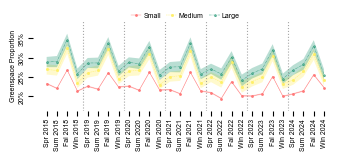

In [7]:
from matplotlib.ticker import PercentFormatter

def create_combined_seasonal_proportion_chart(seasonal_stats):
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 6
    
    width_cm = 10
    height_cm = 3
    width_inch = width_cm / 2.54
    height_inch = height_cm / 2.54
    
    fig, ax = plt.subplots(figsize=(width_inch, height_inch))
    ax.set_frame_on(False)

    city_styles = {
        'Small': {'color': '#ff6b6b', 'marker': 'o', 'linestyle': '-', 'linewidth': 0.3, 'markersize': 1, 'label': 'Small', 'alpha': 0.9},
        'Medium': {'color': '#ffee58', 'marker': 's', 'linestyle': '--', 'linewidth': 0.3, 'markersize': 1, 'label': 'Medium', 'alpha': 0.9},
        'Large': {'color': '#1a936f', 'marker': '^', 'linestyle': '-.', 'linewidth': 0.3, 'markersize': 1, 'label': 'Large','alpha': 0.9}
    }

    seasonal_stats = seasonal_stats.sort_values(['year', 'season_order', 'city_size'])

    unique_times = seasonal_stats[['year', 'season', 'season_order', 'time_label']].drop_duplicates()
    unique_times = unique_times.sort_values(['year', 'season_order'])
    time_labels = unique_times['time_label'].tolist()

    x_positions = np.arange(len(time_labels))

    for city_size in ['Small', 'Medium', 'Large']:
        city_data = seasonal_stats[seasonal_stats['city_size'] == city_size]
        city_data = city_data.sort_values(['year', 'season_order'])

        plot_positions = []
        plot_values = []
        ci_lower = []
        ci_upper = []
        time_labels_for_city = []

        time_to_position = {label: i for i, label in enumerate(time_labels)}

        for _, row in city_data.iterrows():
            if row['time_label'] in time_to_position:
                pos = time_to_position[row['time_label']]
                plot_positions.append(pos)
                plot_values.append(row['mean_green_proportion'])
                ci_lower.append(row['ci_lower'])
                ci_upper.append(row['ci_upper'])
                time_labels_for_city.append(row['time_label'])

        if plot_positions:
            style = city_styles[city_size]

            ax.plot(plot_positions, plot_values,
                    color=style['color'],
                    linestyle=style['linestyle'],
                    linewidth=style['linewidth'],
                    marker=style['marker'],
                    markersize=style['markersize'],
                    label=style['label'],
                    markerfacecolor='white',
                    markeredgecolor=style['color'],
                    markeredgewidth=1,
                    alpha=style['alpha'],
                    zorder=5)

            ax.fill_between(plot_positions, ci_lower, ci_upper,
                           alpha=0.3, color=style['color'],
                           edgecolor='none',
                           zorder=1)

            if len(plot_positions) <= 20:
                for pos, val, time_label in zip(plot_positions, plot_values, time_labels_for_city):
                    season = time_label.split()[0]
                    if season in ['Spring', 'Summer']:
                        ax.annotate(f'{val:.3f}',
                                   xy=(pos, val),
                                   xytext=(0, 6), 
                                   textcoords='offset points',
                                   ha='center',
                                   va='bottom',
                                   fontsize=4,
                                   fontweight='bold',
                                   color=style['color'],
                                   alpha=0.8,
                                   bbox=dict(boxstyle='round,pad=0.1',
                                            facecolor='white',
                                            alpha=0.7,
                                            edgecolor=style['color'],
                                            linewidth=0.5))

    ax.set_xticks(x_positions)
    ax.set_xticklabels(time_labels, rotation=90)

    plt.setp(ax.get_yticklabels(), rotation=90, va='center')

    years = sorted(seasonal_stats['year'].unique())
    year_boundaries = {}

    for year in years:
        year_data = unique_times[unique_times['year'] == year]
        if not year_data.empty:
            last_season_pos = max([time_to_position[label]
                                 for label in year_data['time_label']
                                 if label in time_to_position])
            year_boundaries[year] = last_season_pos

    for year, last_pos in sorted(year_boundaries.items())[:-1]:
        ax.axvline(x=last_pos + 0.5, color='gray', linestyle=':',
                  alpha=0.7, linewidth=0.8, zorder=2)

    ax.set_ylabel('Greenspace Proportion', fontsize=5, labelpad=2)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

    ax.tick_params(axis='both', which='major', labelsize=5, pad=2)

    y_min = seasonal_stats['ci_lower'].min() * 0.9
    y_max = seasonal_stats['ci_upper'].max() * 1.1
    ax.set_ylim(y_min-0.01, y_max)

    ax.legend(loc='upper center', fontsize=5, frameon=False, 
              bbox_to_anchor=(0.5, 1.15), ncol=3,
              handlelength=1.5, handletextpad=0.3, columnspacing=0.8)

    output_path = "combined_city_seasonal_density_trends.pdf"
    fig.savefig(output_path, bbox_inches='tight', facecolor='white', format='pdf')
    print(f"\nChart saved as: {output_path}")

    return fig, ax

fig, ax = create_combined_seasonal_proportion_chart(seasonal_stats)
plt.show()

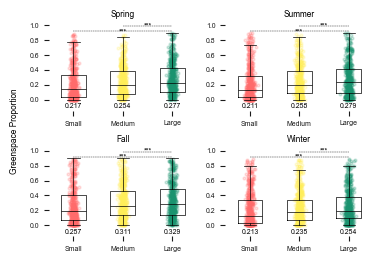

In [9]:
from scipy import stats

df = combined_gdf.copy()
df = df[df['greenspace_proportion'] < 0.9]

season_order = ["spring", "summer", "fall", "winter"]
df["season"] = pd.Categorical(df["season"], categories=season_order, ordered=True)
seasons = [s for s in season_order if s in df["season"].unique()]

city_order = ["Small", "Medium", "Large"]
city_colors = {
    "Small": "#ff6b6b",
    "Medium": "#ffee58",
    "Large": "#1a936f"
}

MAX_SCATTER = 500
def sample_points(group, max_n=MAX_SCATTER):
    if len(group) > max_n:
        return group.sample(max_n, random_state=42)
    return group
scatter_df = df.groupby(["season", "city_size"], group_keys=False).apply(sample_points)

fig, axes = plt.subplots(2, 2, figsize=(3.8, 2.6))

for ax in axes.flat:
    ax.spines['bottom'].set_color('0.1')
    ax.spines['left'].set_color('0.1')
    ax.tick_params(colors='0.1')

axes = axes.flatten()

for ax_idx, (ax, season) in enumerate(zip(axes, seasons)):
    df_season = df[df["season"] == season]
    scatter_season = scatter_df[scatter_df["season"] == season]

    small_city_data = df_season[df_season["city_size"] == "Small"]["greenspace_proportion"].dropna()
    medium_city_data = df_season[df_season["city_size"] == "Medium"]["greenspace_proportion"].dropna()
    large_city_data = df_season[df_season["city_size"] == "Large"]["greenspace_proportion"].dropna()

    def perform_test(data1, data2):
        _, p_normal1 = stats.shapiro(data1.sample(min(5000, len(data1)), random_state=42))
        _, p_normal2 = stats.shapiro(data2.sample(min(5000, len(data2)), random_state=42))
        _, p_levene = stats.levene(data1, data2)

        if p_normal1 > 0.05 and p_normal2 > 0.05 and p_levene > 0.05:
            stat, p_val = stats.ttest_ind(data1, data2, equal_var=(p_levene>0.05))
            test_name = "t-test"
        else:
            stat, p_val = stats.mannwhitneyu(data1, data2, alternative='two-sided')
            test_name = "Mann-Whitney U"
        return p_val, test_name

    p_small_large, test_small_large = perform_test(small_city_data, large_city_data)
    p_medium_large, test_medium_large = perform_test(medium_city_data, large_city_data)

    positions = np.arange(len(city_order))
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    
    ax.set_ylim(0 - 0.15, 1)

    for i, city in enumerate(city_order):
        y_box = df_season[df_season["city_size"] == city]["greenspace_proportion"].dropna()
        mean_val = y_box.mean()

        bp = ax.boxplot(y_box, positions=[i], widths=0.5, showfliers=False, patch_artist=False)
        for element in ["boxes", "whiskers", "caps", "medians"]:
            for item in bp[element]:
                item.set_color("black")
                item.set_linewidth(0.5)

        ax.text(
            i, 
            0-0.05,
            f"{mean_val:.3f}", 
            ha="center", 
            va="top", 
            fontsize=5,
            fontfamily='Arial'
        )

    for i, city in enumerate(city_order):
        y = scatter_season[scatter_season["city_size"] == city]["greenspace_proportion"]
        x = np.random.normal(i, 0.04, size=len(y))
        ax.scatter(x, y, s=4, alpha=0.2, color=city_colors[city])

    ax.set_xticks(positions)
    ax.set_xticklabels(city_order, rotation=0, fontsize=5, fontfamily='Arial')

    ax.tick_params(axis='y', labelsize=5)
    y_labels = ax.get_yticklabels()
    for label in y_labels:
        label.set_fontfamily('Arial')

    ax.set_title(season.capitalize(), fontsize=6, fontfamily='Arial')

    ymax = max([small_city_data.max(), medium_city_data.max(), large_city_data.max()])
    text_height = ymax

    if p_small_large < 0.001:
        stars = "***"
    elif p_small_large < 0.01:
        stars = "**"
    elif p_small_large < 0.05:
        stars = "*"
    else:
        stars = ""
    if stars:
        ax.hlines(text_height + 0.02, xmin=0, xmax=2, color='black', linewidth=0.3, linestyle='--')
        ax.text(1, text_height - 0.02, stars, ha="center", va="bottom", fontsize=5, fontfamily='Arial')

    if p_medium_large < 0.001:
        stars = "***"
    elif p_medium_large < 0.01:
        stars = "**"
    elif p_medium_large < 0.05:
        stars = "*"
    else:
        stars = ""
    if stars:
        ax.hlines(text_height + 0.09, xmin=1, xmax=2, color='black', linewidth=0.3, linestyle='--')
        ax.text(1.5, text_height + 0.06, stars, ha="center", va="bottom", fontsize=5, fontfamily='Arial')

fig.supylabel("Greenspace Proportion", x=0.02, fontsize=6, fontfamily='Arial')

plt.tight_layout()

plt.savefig("greenspace_density_boxplot.pdf", format='pdf', bbox_inches='tight')
plt.show()

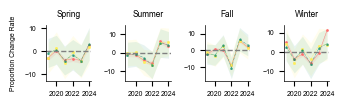

In [11]:
plt.rcParams['font.size'] = 5

stats_df = df.groupby(["year", "season", "city_size"])["greenspace_proportion"].agg(['mean', 'std', 'count']).reset_index()
stats_df = stats_df[stats_df['mean'] < 0.9]

stats_df['se'] = stats_df['std'] / np.sqrt(stats_df['count'])

mean_df = stats_df[['year', 'season', 'city_size', 'mean']].copy()
mean_df = mean_df.rename(columns={'mean': 'greenspace_proportion'})

mean_df["change_rate"] = mean_df.groupby(["season", "city_size"])["greenspace_proportion"].pct_change() * 100

mean_df = mean_df.merge(stats_df[['year', 'season', 'city_size', 'se']], 
                        on=['year', 'season', 'city_size'])

mean_df['change_rate_se'] = mean_df.groupby(["season", "city_size"]).apply(
    lambda x: (100 / x['greenspace_proportion'].shift(1)) * np.sqrt(
        x['se']**2 + x['se'].shift(1)**2
    )
).reset_index(level=[0, 1], drop=True)

city_styles = {
    'Small': {'color': '#ff6b6b', 'marker': 'o', 'linestyle': '-', 'linewidth': 0.3, 'markersize': 1, 'label': 'Small Cities', 'alpha': 0.9},
    'Medium': {'color': '#ffee58', 'marker': 's', 'linestyle': '--', 'linewidth': 0.3, 'markersize': 1, 'label': 'Medium Cities', 'alpha': 0.9},
    'Large': {'color': '#1a936f', 'marker': '^', 'linestyle': '-.', 'linewidth': 0.3, 'markersize': 1, 'label': 'Large Cities', 'alpha': 0.9}
}

city_order = ["Small", "Medium", "Large"]

fig_width_cm = 8.6
fig_height_cm = 2.6
fig_width_inch = fig_width_cm / 2.54
fig_height_inch = fig_height_cm / 2.54

fig, axes = plt.subplots(1, 4, figsize=(fig_width_inch, fig_height_inch))
axes = axes.flatten()

for ax, season in zip(axes, seasons):
    sub_df = mean_df[mean_df["season"] == season]
    for city in city_order:
        city_df = sub_df[sub_df["city_size"] == city].copy()
        style = city_styles[city]
        
        city_df = city_df.dropna(subset=['change_rate', 'change_rate_se'])
        
        if len(city_df) > 0:
            
            city_df['ci_lower'] = city_df['change_rate'] - 1.96 * city_df['change_rate_se']
            city_df['ci_upper'] = city_df['change_rate'] + 1.96 * city_df['change_rate_se']

            ax.plot(
                city_df["year"],
                city_df["change_rate"],
                marker=style['marker'],
                linestyle=style['linestyle'],
                color=style['color'],
                linewidth=style['linewidth'],
                markersize=style['markersize'],
                alpha=style['alpha'],
                label=style['label']
            )

            ax.fill_between(
                city_df["year"],
                city_df["ci_lower"],
                city_df["ci_upper"],
                color=style['color'],
                alpha=0.1,  # 半透明
                linewidth=0
            )
    
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(season.capitalize(), fontsize=6)
    ax.set_xticks([2020, 2022, 2024])
    ax.tick_params(axis='both', which='major', labelsize=5)

    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.supylabel("Proportion Change Rate", x=0.02, fontsize=5)

plt.tight_layout()

plt.savefig('greenspace_change_rate.pdf', format='pdf', bbox_inches='tight')
plt.show()

SPRING GREENSPACE Proportion STATISTICAL SUMMARY
Total cities/regions analyzed: 63,081
Proportion range: 0.0000 - 0.8999
Mean Proportion: 0.2335
Median Proportion: 0.1532
Standard deviation: 0.2252
Coefficient of variation: 96.4%

SUMMER GREENSPACE Proportion STATISTICAL SUMMARY
Total cities/regions analyzed: 62,572
Proportion range: 0.0000 - 0.9000
Mean Proportion: 0.2311
Median Proportion: 0.1519
Standard deviation: 0.2261
Coefficient of variation: 97.8%

FALL GREENSPACE Proportion STATISTICAL SUMMARY
Total cities/regions analyzed: 61,505
Proportion range: 0.0000 - 0.9000
Mean Proportion: 0.2811
Median Proportion: 0.2162
Standard deviation: 0.2364
Coefficient of variation: 84.1%

WINTER GREENSPACE Proportion STATISTICAL SUMMARY
Total cities/regions analyzed: 63,125
Proportion range: 0.0000 - 0.9000
Mean Proportion: 0.2323
Median Proportion: 0.1587
Standard deviation: 0.2225
Coefficient of variation: 95.8%



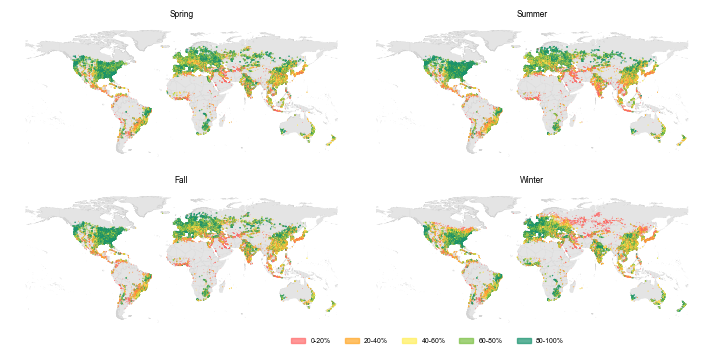

In [12]:
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams['font.family'] = 'Arial'

seasons = ['spring', 'summer', 'fall', 'winter']
season_titles = {
    'spring': 'Spring',
    'summer': 'Summer', 
    'fall': 'Fall',
    'winter': 'Winter'
}

adm0_gdf = gpd.read_file("geoBoundariesCGAZ_ADM0/geoBoundariesCGAZ_ADM0.shp")

fig, axes = plt.subplots(2, 2, figsize=(18/2.54, 18/2.54 * 0.5))
axes = axes.flatten()

all_stats = []

for idx, season in enumerate(seasons):
    ax = axes[idx]
    ax.set_aspect('equal')
    ax.set_frame_on(False)

    season_data = combined_gdf[combined_gdf['season'] == season].copy()
    season_data = season_data[season_data['greenspace_proportion'] < 0.9]

    if season_data.crs is None:
        season_data = season_data.set_crs('EPSG:4326')
    elif season_data.crs != 'EPSG:4326':
        season_data = season_data.to_crs('EPSG:4326')

    if 'year' in season_data.columns:
        mean_Proportion = season_data.groupby('ORIG_FID')['greenspace_proportion'].mean().reset_index()
        mean_Proportion.columns = ['ORIG_FID', 'mean_greenspace_proportion']

        city_geom = season_data.drop_duplicates('ORIG_FID')[['ORIG_FID', 'geometry']]
        mean_Proportion = mean_Proportion.merge(city_geom, on='ORIG_FID')
        plot_gdf = gpd.GeoDataFrame(mean_Proportion, geometry='geometry')
        Proportion_values = plot_gdf['mean_greenspace_proportion']
    else:
        plot_gdf = season_data[['ORIG_FID', 'greenspace_proportion', 'geometry']].copy()
        Proportion_values = plot_gdf['greenspace_proportion']

    adm0_gdf.plot(ax=ax, color='lightgray', alpha=0.6)
    adm0_gdf.boundary.plot(ax=ax, color='lightgray', linewidth=0.1, alpha=1)

    percentiles = Proportion_values.quantile([0.2, 0.4, 0.6, 0.8])

    colors = []
    sizes = []
    
    for value in Proportion_values:
        if value <= percentiles.iloc[0]:
            colors.append('#ff6b6b')  
            sizes.append(0.2)
        elif value <= percentiles.iloc[1]:
            colors.append('#ffa726')  
            sizes.append(0.4)
        elif value <= percentiles.iloc[2]:
            colors.append('#ffee58')  
            sizes.append(0.6)
        elif value <= percentiles.iloc[3]:
            colors.append('#7bc043')  
            sizes.append(0.8)
        else:
            colors.append('#1a936f')  
            sizes.append(1)

    plot_gdf['center'] = plot_gdf.geometry.centroid
    plot_gdf['x'] = plot_gdf.center.x
    plot_gdf['y'] = plot_gdf.center.y

    scatter = ax.scatter(plot_gdf['x'], plot_gdf['y'],
                        c=colors, s=sizes,
                        alpha=0.7, linewidth=0,
                        zorder=5)

    ax.set_title(f'{season_titles[season]}', fontsize=6, pad=5)

    ax.set_xticks([])
    ax.set_yticks([])

    total_cities = len(plot_gdf)
    mean_Proportion_val = Proportion_values.mean()
    std_Proportion_val = Proportion_values.std()
    min_Proportion = Proportion_values.min()
    max_Proportion = Proportion_values.max()

    all_stats.append({
        'season': season_titles[season],
        'total_cities': total_cities,
        'mean_Proportion': mean_Proportion_val,
        'std_Proportion': std_Proportion_val,
        'min_Proportion': min_Proportion,
        'max_Proportion': max_Proportion
    })

    print("="*60)
    print(f"{season_titles[season].upper()} GREENSPACE Proportion STATISTICAL SUMMARY")
    print("="*60)
    print(f"Total cities/regions analyzed: {total_cities:,}")
    print(f"Proportion range: {min_Proportion:.4f} - {max_Proportion:.4f}")
    print(f"Mean Proportion: {mean_Proportion_val:.4f}")
    print(f"Median Proportion: {Proportion_values.median():.4f}")
    print(f"Standard deviation: {std_Proportion_val:.4f}")
    print(f"Coefficient of variation: {(std_Proportion_val/mean_Proportion_val*100):.1f}%")
    print()

legend_patches = [
    mpatches.Patch(color='#ff6b6b', label='0-20%', alpha=0.7),
    mpatches.Patch(color='#ffa726', label='20-40%', alpha=0.7),
    mpatches.Patch(color='#ffee58', label='40-60%', alpha=0.7),
    mpatches.Patch(color='#7bc043', label='60-80%', alpha=0.7),
    mpatches.Patch(color='#1a936f', label='80-100%', alpha=0.7)
]

fig.legend(handles=legend_patches,
           loc='lower center',
           ncol=5,
           #title='Greenspace Proportion Percentiles',
           fontsize=5,
           title_fontsize=6,
           frameon=False,

plt.tight_layout(rect=[0, 0.01, 1, 1]) 

plt.savefig('global_seasonal_greenspace_density.pdf', bbox_inches='tight', facecolor='white', format='pdf')

plt.show()

In [13]:
seasonal_stats = combined_gdf.groupby([
    'year', 'season', 'season_order', 'time_label', 'city_size', 'division'
]).agg({
    'greenspace_proportion': ['mean', 'std', 'count', 'sem']
}).reset_index()

seasonal_stats.columns = [
    'year', 'season', 'season_order', 'time_label', 'city_size', 'division',
    'mean_green_Proportion', 'std_green_Proportion', 'sample_count', 'std_error'
]

seasonal_stats = seasonal_stats.sort_values(['year', 'season_order', 'city_size', 'division'])

seasonal_stats['time_id'] = seasonal_stats['year'].astype(str) + '_' + seasonal_stats['season_order'].astype(str)

unique_times = seasonal_stats[['year', 'season', 'season_order', 'time_label']].drop_duplicates()
unique_times = unique_times.sort_values(['year', 'season_order'])
time_mapping = {f"{row['year']}_{row['season_order']}": idx
                for idx, (_, row) in enumerate(unique_times.iterrows())}
seasonal_stats['time_index'] = seasonal_stats['time_id'].map(time_mapping)

seasonal_stats['ci_lower'] = (seasonal_stats['mean_green_Proportion'] - 1.96 * seasonal_stats['std_error']).clip(lower=0)
seasonal_stats['ci_upper'] = seasonal_stats['mean_green_Proportion'] + 1.96 * seasonal_stats['std_error']

seasonal_stats['full_time_label'] = seasonal_stats['time_label'] + ' (' + seasonal_stats['city_size'] + ')'

print(f"Seasonal Proportion statistics prepared:")
print(f"  Total data points: {len(seasonal_stats)}")
print(f"  Time periods: {seasonal_stats['time_label'].nunique()}")
print(f"  City sizes: {seasonal_stats['city_size'].unique()}")
print(f"  Divisions: {seasonal_stats['division'].unique()}")
print(f"  Proportion range: {seasonal_stats['mean_green_Proportion'].min():.4f} to {seasonal_stats['mean_green_Proportion'].max():.4f}")

print("\nSample of seasonal proportion statistics:")
print(seasonal_stats[['year', 'season', 'city_size', 'division', 'mean_green_Proportion', 'std_error']].head(12))

Seasonal Proportion statistics prepared:
  Total data points: 168
  Time periods: 28
  City sizes: ['Large' 'Medium' 'Small']
  Divisions: ['Global North' 'Global South']
  Proportion range: 0.1253 to 0.4987

Sample of seasonal proportion statistics:
    year  season city_size      division  mean_green_Proportion  std_error
6   2018  spring     Large  Global North               0.424529   0.009219
7   2018  spring     Large  Global South               0.163969   0.005685
8   2018  spring    Medium  Global North               0.402197   0.009577
9   2018  spring    Medium  Global South               0.155719   0.005863
10  2018  spring     Small  Global North               0.299122   0.001362
11  2018  spring     Small  Global South               0.167724   0.001122
12  2018  summer     Large  Global North               0.442984   0.010321
13  2018  summer     Large  Global South               0.153593   0.005610
14  2018  summer    Medium  Global North               0.405591   0.010140

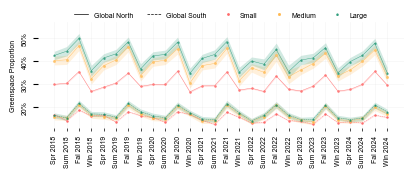

In [14]:
def create_combined_seasonal_proportion_chart(seasonal_stats):

    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 5

    fig, ax = plt.subplots(
        figsize=(12 / 2.54, 3.5 / 2.54)  # 10cm × 4cm
    )
    ax.set_frame_on(False)

    region_styles = {
        'Global North': {
            'Small':  {'color': '#ff6b6b', 'marker': 'o', 'linestyle': '-',  'linewidth': 0.3, 'markersize': 1},
            'Medium': {'color': '#ffb74d', 'marker': 's', 'linestyle': '-',  'linewidth': 0.3, 'markersize': 1},
            'Large':  {'color': '#1a936f', 'marker': '^', 'linestyle': '-',  'linewidth': 0.3, 'markersize': 1}
        },
        'Global South': {
            'Small':  {'color': '#ff6b6b', 'marker': 'o', 'linestyle': '--', 'linewidth': 0.3, 'markersize': 1},
            'Medium': {'color': '#ffb74d', 'marker': 's', 'linestyle': '--', 'linewidth': 0.3, 'markersize': 1},
            'Large':  {'color': '#1a936f', 'marker': '^', 'linestyle': '--', 'linewidth': 0.3, 'markersize': 1}
        }
    }

    seasonal_stats = seasonal_stats.sort_values(
        ['year', 'season_order', 'division', 'city_size']
    )

    unique_times = seasonal_stats[['year', 'season', 'season_order', 'time_label']].drop_duplicates()
    unique_times = unique_times.sort_values(['year', 'season_order'])
    time_labels = unique_times['time_label'].tolist()
    x_positions = np.arange(len(time_labels))
    time_to_position = {label: i for i, label in enumerate(time_labels)}

    for division in ['Global North', 'Global South']:
        for city_size in ['Small', 'Medium', 'Large']:

            city_data = seasonal_stats[
                (seasonal_stats['division'] == division) &
                (seasonal_stats['city_size'] == city_size)
            ]

            if city_data.empty:
                continue

            city_data = city_data.sort_values(['year', 'season_order'])

            pos, val, low, up = [], [], [], []

            for _, row in city_data.iterrows():
                if row['time_label'] in time_to_position:
                    p = time_to_position[row['time_label']]
                    pos.append(p)
                    val.append(row['mean_green_Proportion'])
                    low.append(row['ci_lower'])
                    up.append(row['ci_upper'])

            style = region_styles[division][city_size]

            ax.plot(
                pos, val,
                color=style['color'],
                linestyle=style['linestyle'],
                linewidth=style['linewidth'],
                marker=style['marker'],
                markersize=style['markersize'],
                markerfacecolor='white' if division == 'Global North' else style['color'],
                markeredgecolor=style['color'],
                markeredgewidth=0.8,
                alpha=0.9
            )

            ax.fill_between(
                pos, low, up,
                color=style['color'],
                alpha=0.2,
                linewidth=0
            )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(time_labels, rotation=90, fontsize=5)
    plt.setp(ax.get_yticklabels(), rotation=90, va='center')

    ax.tick_params(axis='y', labelsize=5)
    ax.tick_params(axis='x', length=2, width=0.5)

    from matplotlib.ticker import PercentFormatter
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

    y_min = seasonal_stats['ci_lower'].min() * 0.9
    y_max = seasonal_stats['ci_upper'].max() * 1.1
    ax.set_ylim(max(0, y_min), y_max)

    ax.set_ylabel('Greenspace Proportion', fontsize=5)

    ax.grid(True, alpha=0.15, linewidth=0.4)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', linestyle='-',  linewidth=0.5, label='Global North'),
        Line2D([0], [0], color='black', linestyle='--', linewidth=0.5, label='Global South'),
        Line2D([0], [0], color='#ff6b6b', marker='o', linestyle='None', markersize=1, label='Small'),
        Line2D([0], [0], color='#ffb74d', marker='s', linestyle='None', markersize=1, label='Medium'),
        Line2D([0], [0], color='#1a936f', marker='^', linestyle='None', markersize=1, label='Large')
    ]

    ax.legend(
        handles=legend_elements,
        loc='upper center',
        ncol=5,
        frameon=False,
        fontsize=5,
        bbox_to_anchor=(0.5, 1.15)
    )
    
    #plt.tight_layout(pad=0.3)

    output_path = "combined_region_city_seasonal_density_trends.pdf"
    fig.savefig(output_path, format='pdf', bbox_inches='tight')

    return fig, ax


fig, ax = create_combined_seasonal_proportion_chart(seasonal_stats)
plt.show()

In [15]:
mean_df = df.groupby(["year", "season", "city_size", "division"])["greenspace_proportion"].mean().reset_index()

mean_df["change_rate"] = mean_df.groupby(["season", "city_size", "division"])["greenspace_proportion"].pct_change() * 100

print("Updated mean_df with division and change_rate:")
print(mean_df.head())
print(mean_df.info())

Updated mean_df with division and change_rate:
   year  season city_size      division  greenspace_proportion  change_rate
0  2018  spring     Large  Global North               0.424529          NaN
1  2018  spring     Large  Global South               0.163969          NaN
2  2018  spring    Medium  Global North               0.402197          NaN
3  2018  spring    Medium  Global South               0.155719          NaN
4  2018  spring     Small  Global North               0.299122          NaN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   year                   168 non-null    int64   
 1   season                 168 non-null    category
 2   city_size              168 non-null    object  
 3   division               168 non-null    object  
 4   greenspace_proportion  168 non-null    float64 
 5   change_rate      

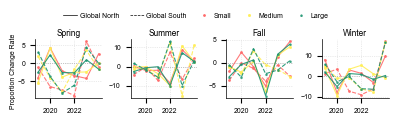

In [16]:
from matplotlib.lines import Line2D

city_styles = {
    'Small': {'color': '#ff6b6b', 'marker': 'o', 'markersize': 1, 'label': 'Small Cities', 'alpha': 0.9},
    'Medium': {'color': '#ffee58', 'marker': 's', 'markersize': 1, 'label': 'Medium Cities', 'alpha': 0.9},
    'Large': {'color': '#1a936f', 'marker': '^', 'markersize': 1, 'label': 'Large Cities','alpha': 0.9}
}

city_order = ["Small", "Medium", "Large"]

fig, axes = plt.subplots(1, 4, figsize=(4, 1))
axes = axes.flatten()

for ax, season in zip(axes, seasons):
    sub_df = mean_df[mean_df["season"] == season].sort_values(['year', 'division', 'city_size'])

    for city in city_order:
        for division in ['Global North', 'Global South']:
            city_division_df = sub_df[(sub_df["city_size"] == city) & (sub_df["division"] == division)]
            city_division_df = city_division_df[city_division_df['greenspace_proportion'] < 0.9]

            linestyle = '-' if division == 'Global North' else '--'
            color = city_styles[city]['color']
            marker = city_styles[city]['marker']
            markersize = city_styles[city]['markersize']
            alpha = city_styles[city]['alpha']

            ax.plot(
                city_division_df["year"],
                city_division_df["change_rate"],
                marker=marker,
                linestyle=linestyle,
                color=color,
                linewidth=0.8,
                markersize=markersize,
                alpha=alpha,
            )

    ax.axhline(0, color="gray", linestyle=":", linewidth=0.5, alpha=0.7)
    ax.set_title(season.capitalize(), fontsize=6, pad=2)
    ax.set_xticks([2020, 2022])
    ax.tick_params(axis='x', labelsize=5)
    ax.tick_params(axis='y', labelsize=5)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, linestyle=':', alpha=0.5, linewidth=0.5)

fig.supylabel("Proportion Change Rate", x=0.035, fontsize=5)

legend_elements = [
    Line2D([0], [0], color='black', linestyle='-', linewidth=0.5, label='Global North'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=0.5, label='Global South'),
    Line2D([0], [0], color='#ff6b6b', marker='o', linestyle='None', markersize=1, label='Small'),
    Line2D([0], [0], color='#ffee58', marker='s', linestyle='None', markersize=1, label='Medium'),
    Line2D([0], [0], color='#1a936f', marker='^', linestyle='None', markersize=1, label='Large')
]

fig.legend(
    handles=legend_elements, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.15), 
    ncol=5, 
    fontsize=5, 
    frameon=False,
    columnspacing=1.5,
    handletextpad=0.4
)

plt.tight_layout(rect=[0, 0, 1, 1])

output_filename = 'greenspace_change_rate_by_division.pdf'
fig.savefig(output_filename, bbox_inches='tight', facecolor='white', format='pdf')

plt.show()

In [17]:
df_regression = combined_gdf[
    (combined_gdf['greenspace_proportion'] < 0.9) &
    (combined_gdf['gdp_per_capita'] > 0)
].copy()

df_regression['log10_gdp_per_capita'] = np.log10(df_regression['gdp_per_capita'])

season_order = ['spring', 'summer', 'fall', 'winter']
df_regression['season'] = pd.Categorical(
    df_regression['season'], categories=season_order, ordered=True
)

city_size_order = ['Small', 'Medium', 'Large']
df_regression['city_size'] = pd.Categorical(
    df_regression['city_size'], categories=city_size_order, ordered=True
)

print(f"DataFrame for regression prepared with shape: {df_regression.shape}")
print(f"Columns: {list(df_regression.columns)}")
print(f"Sample of transformed data:")
print(df_regression[['greenspace_proportion', 'gdp_SUM', 'log10_gdp_per_capita', 'season', 'city_size']].head())

DataFrame for regression prepared with shape: (1609824, 32)
Columns: ['ORIG_FID', 'urbanArea', 'geometry', 'greenspace_total_m2', 'greenspace_total_km2', 'year', 'season_NH', 'hemisphere', 'season', 'season_order', 'time_id', 'time_label', 'pop_sum', 'expo_100m', 'expo_500m', 'expo_1000m', 'expo_1500m', 'expo_100m_pc', 'expo_500m_pc', 'expo_1000m_pc', 'expo_1500m_pc', 'countrycode', 'country', 'division', 'gdp_MEAN', 'gdp_SUM', 'pop_MEAN', 'pop_SUM', 'gdp_per_capita', 'city_size', 'greenspace_proportion', 'log10_gdp_per_capita']
Sample of transformed data:
   greenspace_proportion     gdp_SUM  log10_gdp_per_capita  season city_size
0               0.204215  51230524.0              4.495534  spring     Small
1               0.114059  51230524.0              4.495534  spring     Small
2               0.152686  51230524.0              4.495534  spring     Small
3               0.201889  51230524.0              4.495534  spring     Small
4               0.209927  51230524.0              4.

In [18]:
import statsmodels.api as sm

df_regression = df_regression.copy()
df_regression['log10_gdp_sq'] = df_regression['log10_gdp_per_capita'] ** 2

def ekc_regression(df):
    """
    EKC: y = b0 + b1*logGDP + b2*(logGDP)^2
    """
    X = df[['log10_gdp_per_capita', 'log10_gdp_sq']]
    X = sm.add_constant(X)
    y = df['greenspace_proportion']

    model = sm.OLS(y, X).fit()
    return model

def ekc_diagnosis(model):
    b1 = model.params['log10_gdp_per_capita']
    b2 = model.params['log10_gdp_sq']
    p2 = model.pvalues['log10_gdp_sq']

    if p2 < 0.05:
        if b1 > 0 and b2 < 0:
            shape = 'Inverted-U (EKC)'
        elif b1 < 0 and b2 > 0:
            shape = 'U-shape'
        else:
            shape = 'Non-classical'
    else:
        shape = 'Monotonic'

    # turning point（log10 GDP）
    turning_point = -b1 / (2 * b2) if b2 != 0 else None

    return shape, turning_point

season_order = ['spring', 'summer', 'fall', 'winter']
city_order = ['Small', 'Medium', 'Large']

ekc_results = []

for season in season_order:
    for city_size in city_order:

        sub = df_regression[
            (df_regression['season'] == season) &
            (df_regression['city_size'] == city_size)
        ]
        print(season, city_size, len(sub))

        if len(sub) >= 10:  # EKC 至少需要一定样本量
            model = ekc_regression(sub)
            shape, tp = ekc_diagnosis(model)

            ekc_results.append({
                'season': season,
                'city_size': city_size,
                'shape': shape,
                'turning_log10_gdp': tp,
                'b1': model.params['log10_gdp_per_capita'],
                'b2': model.params['log10_gdp_sq'],
                'r2': model.rsquared,
                'p_b2': model.pvalues['log10_gdp_sq']
            })

ekc_summary = pd.DataFrame(ekc_results)
print(ekc_summary)

spring Small 401166
spring Medium 7015
spring Large 6848
summer Small 389909
summer Medium 6774
summer Large 6602
fall Small 379204
fall Medium 6603
fall Large 6408
winter Small 386122
winter Medium 6664
winter Large 6509
    season city_size    shape  turning_log10_gdp        b1        b2  \
0   spring     Small  U-shape           3.691270 -0.876727  0.118757   
1   spring    Medium  U-shape           3.563756 -1.081437  0.151727   
2   spring     Large  U-shape           3.479430 -1.165771  0.167523   
3   summer     Small  U-shape           3.222127 -0.589784  0.091521   
4   summer    Medium  U-shape           2.794178 -0.495809  0.088722   
5   summer     Large  U-shape           3.158858 -0.889463  0.140789   
6     fall     Small  U-shape           3.355106 -0.745159  0.111048   
7     fall    Medium  U-shape           3.326125 -0.892028  0.134094   
8     fall     Large  U-shape           3.361997 -1.096677  0.163099   
9   winter     Small  U-shape           3.816880 -1.142858

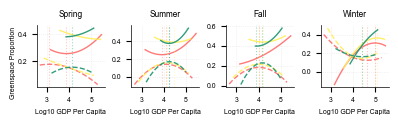

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.lines import Line2D

df_regression = combined_gdf[
    (combined_gdf['greenspace_proportion'] < 0.9) &
    (combined_gdf['gdp_per_capita'] > 0)
].copy()

df_regression['log10_gdp_per_capita'] = np.log10(df_regression['gdp_per_capita'])
df_regression['log10_gdp_sq'] = df_regression['log10_gdp_per_capita'] ** 2

season_order = ['spring', 'summer', 'fall', 'winter']
df_regression['season'] = pd.Categorical(
    df_regression['season'],
    categories=season_order,
    ordered=True
)

city_size_order = ['Small', 'Medium', 'Large']
df_regression['city_size'] = pd.Categorical(
    df_regression['city_size'],
    categories=city_size_order,
    ordered=True
)

def ekc_regression(df):
    X = df[['log10_gdp_per_capita', 'log10_gdp_sq']]
    X = sm.add_constant(X)
    y = df['greenspace_proportion']
    return sm.OLS(y, X).fit()

def ekc_turning_point(model):
    b1 = model.params['log10_gdp_per_capita']
    b2 = model.params['log10_gdp_sq']
    return -b1 / (2 * b2) if b2 != 0 else None

city_colors = {
    'Small': '#ff6b6b',
    'Medium': '#ffee58',
    'Large': '#1a936f'
}

division_styles = {
    'Global North': '-',
    'Global South': '--'
}

fig, axes = plt.subplots(
    1, 4,
    figsize=(4, 1.2),
)

axes = axes.flatten()

for i, season in enumerate(season_order):
    ax = axes[i]

    for city_size in city_size_order:
        for division in ['Global North', 'Global South']:

            sub = df_regression[
                (df_regression['season'] == season) &
                (df_regression['city_size'] == city_size) &
                (df_regression['division'] == division)
            ]

            if len(sub) < 15:
                continue

            model = ekc_regression(sub)
            tp = ekc_turning_point(model)

            gdp_seq = np.linspace(
                sub['log10_gdp_per_capita'].min(),
                sub['log10_gdp_per_capita'].max(),
                200
            )

            X_pred = sm.add_constant(
                np.column_stack([gdp_seq, gdp_seq ** 2])
            )
            y_pred = model.predict(X_pred)

            ax.plot(
                gdp_seq,
                y_pred,
                linestyle=division_styles[division],
                linewidth=1.0,
                color=city_colors[city_size],
                alpha=0.9
            )

            if tp is not None and gdp_seq.min() < tp < gdp_seq.max():
                ax.axvline(
                    tp,
                    linestyle=':',
                    color=city_colors[city_size],
                    alpha=0.4,
                    linewidth=0.8
                )

    ax.set_title(season.capitalize(), fontsize=6, fontweight='normal')
    ax.set_xlabel('Log10 GDP Per Capita', fontsize=5)
    #ax.set_ylabel('Greenspace Proportion', fontsize=5)
    fig.supylabel("Greenspace Proportion", x=0.035, fontsize=5)
 
    ax.tick_params(axis='both', which='major', labelsize=5)
    ax.tick_params(axis='both', which='minor', labelsize=4)
    
    ax.grid(True, linestyle=':', alpha=0.3, linewidth=0.5)

    for spine in ax.spines.values():
        spine.set_linewidth(0.5) 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

legend_elements = [
    Line2D([0], [0], color='black', linestyle='-', linewidth=0.5, label='Global North'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=0.5, label='Global South'),
    Line2D([0], [0], color='#ff6b6b', marker='o', linestyle='None', markersize=1, label='Small Cities'),
    Line2D([0], [0], color='#ffee58', marker='s', linestyle='None', markersize=1, label='Medium Cities'),
    Line2D([0], [0], color='#1a936f', marker='^', linestyle='None', markersize=1, label='Large Cities')
]


plt.tight_layout(rect=[0, 0, 1, 1])  # 调整rect参数为图例留出空间
plt.savefig('EKC_division.pdf', format='pdf', bbox_inches='tight', facecolor='white')
plt.show()

In [23]:
us_countrycodes = ['USA']
uk_countrycodes = ['GBR']
china_countrycodes = ['CHN']
india_countrycodes = ['IND']
russia_countrycodes = ['RUS']
brazil_countrycodes = ['BRA']
canada_countrycodes = ['CAN']
australia_countrycodes = ['AUS']

western_europe_countrycodes = ['AUT', 'BEL', 'CHE', 'DNK', 'FIN', 'FRA', 'DEU', 'GRC', 'IRL', 'ITA', 'LUX', 'NLD', 'NOR', 'PRT', 'ESP', 'SWE']
eastern_europe_countrycodes = ['ALB', 'BGR', 'BIH', 'BLR', 'HRV', 'CZE', 'EST', 'HUN', 'LVA', 'LTU', 'MDA', 'MKD', 'MNE', 'POL', 'ROU', 'SRB', 'SVK', 'SVN', 'UKR']

middle_east_countrycodes = ['BHR', 'IRN', 'IRQ', 'ISR', 'JOR', 'KWT', 'LBN', 'OMN', 'PSE', 'QAT', 'SAU', 'SYR', 'ARE', 'YEM', 'TUR']
north_africa_countrycodes = ['DZA', 'EGY', 'LBY', 'MAR', 'TUN', 'SDN', 'DJI', 'SOM']

subsaharan_africa_countrycodes = ['AGO', 'BEN', 'BWA', 'BFA', 'BDI', 'CPV', 'CMR', 'CAF', 'TCD', 'COM', 'COG', 'COD', 'CIV', 'GNQ', 'ERI', 'SWZ', 'ETH', 'GAB', 'GMB', 'GHA', 'GIN', 'GNB', 'KEN', 'LSO', 'LBR', 'MDG', 'MWI', 'MLI', 'MRT', 'MUS', 'MOZ', 'NAM', 'NER', 'NGA', 'RWA', 'STP', 'SEN', 'SYC', 'SLE', 'ZAF', 'SSD', 'TZA', 'TGO', 'UGA', 'ZMB', 'ZWE']

latin_america_excl_brazil = ['ARG', 'BOL', 'CHL', 'COL', 'CRI', 'CUB', 'DOM', 'ECU', 'SLV', 'GTM', 'HTI', 'HND', 'JAM', 'MEX', 'NIC', 'PAN', 'PRY', 'PER', 'URY', 'VEN', 'ATG', 'BHS', 'BRB', 'BLZ', 'DMA', 'GRD', 'GUY', 'KNA', 'LCA', 'VCT', 'SUR', 'TTO']

east_asia_countrycodes = ['JPN', 'KOR', 'HKG', 'MAC', 'MNG', 'PRK', 'TWN']
southeast_asia_countrycodes = ['IDN', 'VNM', 'THA', 'PHL', 'MYS', 'SGP', 'KHM', 'LAO', 'MMR', 'TLS', 'BRN']
south_asia_excl_india = ['AFG', 'BGD', 'BTN', 'MDV', 'NPL', 'PAK', 'LKA']
central_asia_countrycodes = ['KAZ', 'KGZ', 'TJK', 'TKM', 'UZB']

other_oceania_countrycodes = ['NZL', 'FJI', 'PNG', 'WSM', 'TON', 'VUT', 'SLB', 'KIR', 'NRU', 'MHL', 'FSM', 'PLW', 'TUV']

countrycode_to_region = {}

for cc in us_countrycodes: countrycode_to_region[cc] = 'United States'
for cc in uk_countrycodes: countrycode_to_region[cc] = 'United Kingdom'
for cc in china_countrycodes: countrycode_to_region[cc] = 'China'
for cc in india_countrycodes: countrycode_to_region[cc] = 'India'
for cc in russia_countrycodes: countrycode_to_region[cc] = 'Russia'
for cc in brazil_countrycodes: countrycode_to_region[cc] = 'Brazil'
for cc in canada_countrycodes: countrycode_to_region[cc] = 'Canada'
for cc in australia_countrycodes: countrycode_to_region[cc] = 'Australia'

for cc in western_europe_countrycodes:
    if cc not in countrycode_to_region:
        countrycode_to_region[cc] = 'Other Western Europe'
for cc in eastern_europe_countrycodes:
    if cc not in countrycode_to_region:
        countrycode_to_region[cc] = 'Other Eastern Europe'
for cc in middle_east_countrycodes:
    if cc not in countrycode_to_region:
        countrycode_to_region[cc] = 'Middle East'
for cc in north_africa_countrycodes:
    if cc not in countrycode_to_region:
        countrycode_to_region[cc] = 'North Africa'
for cc in subsaharan_africa_countrycodes:
    if cc not in countrycode_to_region:
        countrycode_to_region[cc] = 'Sub-Saharan Africa'
for cc in latin_america_excl_brazil:
    if cc not in countrycode_to_region:
        countrycode_to_region[cc] = 'Latin America (excl Brazil)'
for cc in east_asia_countrycodes:
    if cc not in countrycode_to_region:
        countrycode_to_region[cc] = 'East Asia'
for cc in southeast_asia_countrycodes:
    if cc not in countrycode_to_region:
        countrycode_to_region[cc] = 'Southeast Asia'
for cc in south_asia_excl_india:
    if cc not in countrycode_to_region:
        countrycode_to_region[cc] = 'South Asia (excl India)'
for cc in central_asia_countrycodes:
    if cc not in countrycode_to_region:
        countrycode_to_region[cc] = 'Central Asia'
for cc in other_oceania_countrycodes:
    if cc not in countrycode_to_region:
        countrycode_to_region[cc] = 'Other Oceania'

combined_gdf['region_group'] = combined_gdf['countrycode'].map(countrycode_to_region).fillna('Other')

filtered_gdf = combined_gdf[combined_gdf['greenspace_proportion'] < 0.9].copy()

Proportion_by_region_seasonal = filtered_gdf.groupby(['region_group', 'season', 'city_size', 'division'])['greenspace_proportion'].mean().reset_index()

print("Sample of Proportion_by_region_seasonal:")
print(Proportion_by_region_seasonal.head())
print(f"\nShape of Proportion_by_region_seasonal: {Proportion_by_region_seasonal.shape}")

Sample of Proportion_by_region_seasonal:
  region_group  season city_size      division  greenspace_proportion
0    Australia    fall     Large  Global North               0.285374
1    Australia    fall    Medium  Global North               0.262583
2    Australia    fall     Small  Global North               0.256317
3    Australia  spring     Large  Global North               0.255507
4    Australia  spring    Medium  Global North               0.233553

Shape of Proportion_by_region_seasonal: (280, 5)


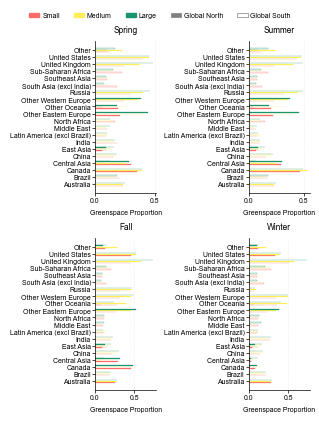

In [24]:
import matplotlib.patches as mpatches

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42


city_colors = {
    'Small': '#ff6b6b',
    'Medium': '#ffee58',
    'Large': '#1a936f'
}
city_size_order = ['Small', 'Medium', 'Large']
division_order = ['Global North', 'Global South']
season_order = ['spring', 'summer', 'fall', 'winter']

Proportion_by_region_seasonal = Proportion_by_region_seasonal.sort_values(
    ['season', 'region_group', 'city_size', 'division']
)

fig_width_cm = 8
fig_height_cm = 10.4
fig_width_inch = fig_width_cm / 2.54
fig_height_inch = fig_height_cm / 2.54

fig, axes = plt.subplots(2, 2, figsize=(fig_width_inch, fig_height_inch))
axes = axes.flatten()

unique_regions = Proportion_by_region_seasonal['region_group'].unique().tolist()
if 'Other' in unique_regions:
    unique_regions.remove('Other')
    unique_regions.append('Other')

bar_height = 0.08
gap_between_division_bars = 0.008
gap_between_city_size_blocks = 0.04

num_city_sizes = len(city_size_order)
num_divisions = len(division_order)

height_per_city_size_block = (bar_height * num_divisions) + gap_between_division_bars * (num_divisions - 1)

total_height_for_region_bars = (height_per_city_size_block * num_city_sizes) + (gap_between_city_size_blocks * (num_city_sizes - 1))

for i, season in enumerate(season_order):
    ax = axes[i]
    season_data = Proportion_by_region_seasonal[Proportion_by_region_seasonal['season'] == season]

    region_y_centers = np.arange(len(unique_regions))

    for region_idx, region_group in enumerate(unique_regions):
        current_region_y_center = region_y_centers[region_idx]

        first_bar_center_in_region = current_region_y_center - (total_height_for_region_bars / 2) + (bar_height / 2)

        for city_size_idx, city_size in enumerate(city_size_order):
            for division_idx, division in enumerate(division_order):
                filtered_data = season_data[
                    (season_data['region_group'] == region_group) &
                    (season_data['city_size'] == city_size) &
                    (season_data['division'] == division)
                ]

                if not filtered_data.empty:
                    mean_Proportion = filtered_data['greenspace_proportion'].values[0]

                    facecolor = city_colors[city_size] if division == 'Global North' else 'white'
                    edgecolor = city_colors[city_size]
                    linewidth = 0.2

                    y_pos = first_bar_center_in_region + \
                            city_size_idx * (height_per_city_size_block + gap_between_city_size_blocks) + \
                            division_idx * (bar_height + gap_between_division_bars)

                    ax.barh(
                        y_pos,
                        mean_Proportion,
                        height=bar_height,
                        facecolor=facecolor,
                        edgecolor=edgecolor,
                        linewidth=linewidth,
                        zorder=2,
                        align='center'
                    )

    ax.set_title(f'{season.capitalize()}', fontsize=6)
    ax.set_xlabel('Greenspace Proportion', fontsize=5)
    ax.set_yticks(region_y_centers)
    ax.set_yticklabels(unique_regions, fontsize=5)
    ax.tick_params(axis='x', labelsize=5, length=2.0, width=0.5, pad=1)
    ax.tick_params(axis='y', labelsize=5, length=2.0, width=0.5, pad=1)

    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.grid(axis='x', linestyle=':', alpha=0.3, linewidth=0.5, zorder=1)
    ax.set_xlim(left=0)

legend_elements = []

for city_size in city_size_order:
    legend_elements.append(mpatches.Patch(color=city_colors[city_size], label=city_size))

legend_elements.append(mpatches.Patch(facecolor='gray', edgecolor='gray', linewidth=0.5, label='Global North'))
legend_elements.append(mpatches.Patch(facecolor='white', edgecolor='gray', linewidth=0.5, label='Global South'))


fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=5, fontsize=5, frameon=False, handlelength=1.5,
    handleheight=0.6,
    handletextpad=0.4
)

plt.tight_layout(rect=[0, 0, 1, 0.98])

output_filename = 'seasonal_greenspace_density_by_region_vertical.pdf'
fig.savefig(output_filename, bbox_inches='tight', facecolor='white', format='pdf')
plt.show()